# 03 — Reference classifier (6 LOSO folds)
> Chạy được cả local lẫn Google Colab (upload thư mục project rồi `%cd` vào `notebooks/`). Training thực tế của dự án được chạy bằng script tương ứng trong `src/` (CPU local); notebook này gọi lại cùng hàm và hiển thị kết quả đã lưu.

Train lại từ đầu: `python src/train_classifier.py --folds 1 2 3 4 5 6 --seeds 0 1 2`. Checkpoint chọn theo **Val accuracy**; Test chỉ đánh giá một lần với checkpoint đã chọn.

In [1]:
import sys, json, warnings
warnings.filterwarnings('ignore')
from pathlib import Path
ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(ROOT / 'src'))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import plotstyle; plotstyle.apply()
from plotstyle import SERIES, TEXT2, METHOD_COLORS
FIG = ROOT / 'results' / 'figures'; SUM = ROOT / 'results' / 'summary'; PRED = ROOT / 'results' / 'predictions'
LOGS = ROOT / 'results' / 'logs'
pd.set_option('display.float_format', '{:.4f}'.format)
from classifier import DigitCNN
from train_classifier import CFG
import torch
m = DigitCNN(); print(m); print('params:', sum(p.numel() for p in m.parameters()))
print('logits shape:', tuple(m(torch.zeros(2, 1, 64, 32)).shape)); CFG

DigitCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
  )
  (head): Linear(in_features=128, out_features=10, bias=True)
)
params: 93962
logits shape: (2, 10)


{'epochs': 60,
 'batch_size': 64,
 'lr': 0.001,
 'weight_decay': 0.0001,
 'optimizer': 'Adam'}

## (Tuỳ chọn) Train lại một fold ngay trong notebook
Đặt `RETRAIN = True` để chạy lại (≈1 phút/fold trên CPU). Mặc định đọc kết quả đã lưu.

In [2]:
RETRAIN = False
if RETRAIN:
    from train_classifier import train_one
    r = train_one(fold=1, seed=0); r.pop('preds'); r

## Learning curves (seed 0)

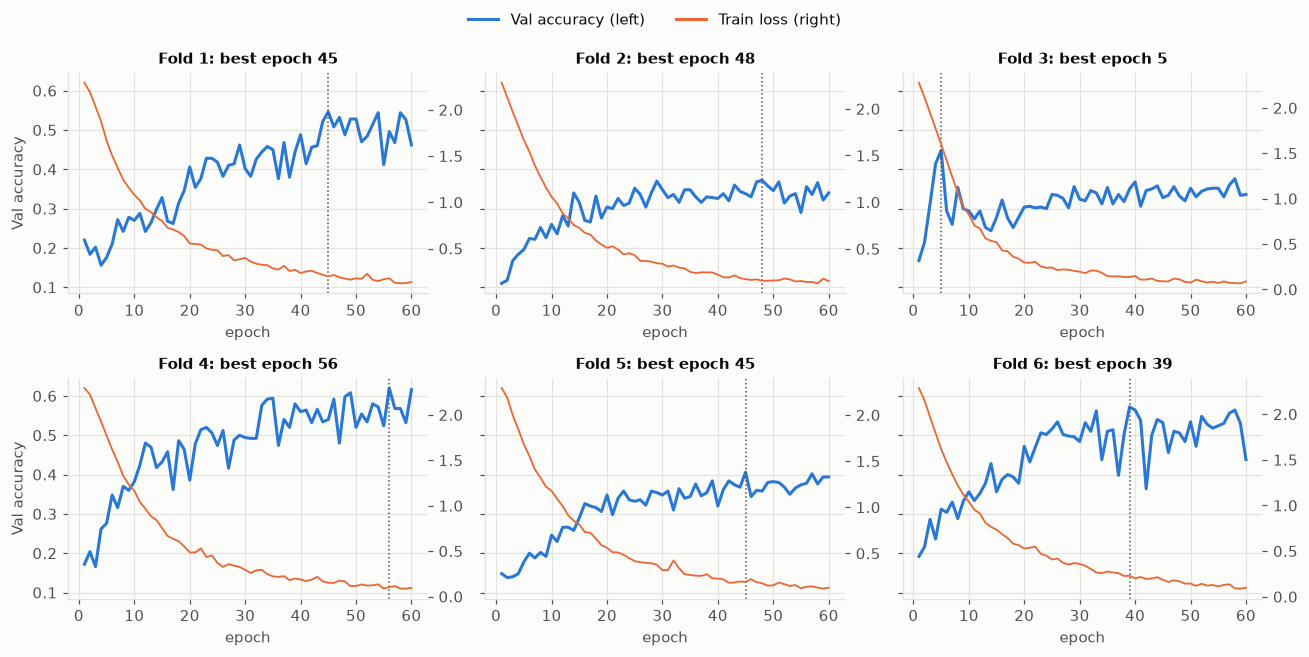

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharey=True)
for ax, fold in zip(axes.ravel(), range(1, 7)):
    h = pd.read_csv(LOGS / f'classifier_fold_{fold}_seed_0_history.csv')
    ax.plot(h.epoch, h.val_acc, color=SERIES[0], label='Val accuracy')
    ax2 = ax.twinx(); ax2.plot(h.epoch, h.train_loss, color=SERIES[1], lw=1.2, label='Train loss'); ax2.grid(False)
    best = h.val_acc.idxmax(); ax.axvline(h.epoch[best], color=TEXT2, ls=':', lw=1)
    ax.set_title(f'Fold {fold}: best epoch {h.epoch[best]}', fontsize=10); ax.set_xlabel('epoch')
axes[0, 0].set_ylabel('Val accuracy'); axes[1, 0].set_ylabel('Val accuracy')
fig.legend(handles=[plt.Line2D([], [], color=SERIES[0]), plt.Line2D([], [], color=SERIES[1])],
           labels=['Val accuracy (left)', 'Train loss (right)'], loc='upper center', ncol=2)
fig.tight_layout(rect=(0, 0, 1, 0.95)); fig.savefig(FIG / 'classifier_learning_curves.png'); plt.show()

## Test accuracy và Macro-F1 trên log-mel gốc (A0)

In [4]:
from sklearn.metrics import f1_score
pr = pd.read_csv(PRED / 'classifier_original_predictions.csv')
tab = pr.groupby(['seed', 'fold']).apply(lambda g: pd.Series({
    'test_speaker': g.speaker.iloc[0], 'Accuracy': g.correct.mean(),
    'Macro_F1': f1_score(g.label, g.prediction, average='macro')}), include_groups=False).reset_index()
display(tab)
display(tab.groupby('seed')[['Accuracy', 'Macro_F1']].agg(['mean', 'std']))
runs = pd.DataFrame(json.load(open(LOGS / 'classifier_train_seeds_0_1_2.json'))['runs'])
runs[['fold', 'seed', 'best_epoch', 'val_acc', 'test_acc']]

,seed,fold,test_speaker,Accuracy,Macro_F1
0,0,1,george,0.5140,0.4877
1,0,2,jackson,0.5620,0.5227
2,0,3,lucas,0.2400,0.1810
3,0,4,nicolas,0.2700,0.2173
4,0,5,theo,0.4380,0.3445
5,0,6,yweweler,0.5160,0.4859
6,1,1,george,0.5400,0.5326
7,1,2,jackson,0.6100,0.5830
8,1,3,lucas,0.2560,0.1967
9,1,4,nicolas,0.3340,0.3028


Accuracy        Macro_F1       
         mean    std     mean    std
seed                                
0      0.4233 0.1367   0.3732 0.1485
1      0.4450 0.1317   0.4056 0.1449
2      0.4573 0.1198   0.4123 0.1307

,fold,seed,best_epoch,val_acc,test_acc
0,1,0,45,0.5460,0.5140
1,2,0,48,0.3720,0.5620
2,3,0,5,0.4480,0.2400
3,4,0,56,0.6200,0.2700
4,5,0,45,0.4060,0.4380
5,6,0,39,0.5720,0.5160
6,1,1,57,0.5880,0.5400
7,2,1,52,0.3640,0.6100
8,3,1,59,0.3440,0.2560
9,4,1,56,0.5820,0.3340


## Confusion matrix (Original, seed 0, gộp 6 fold)

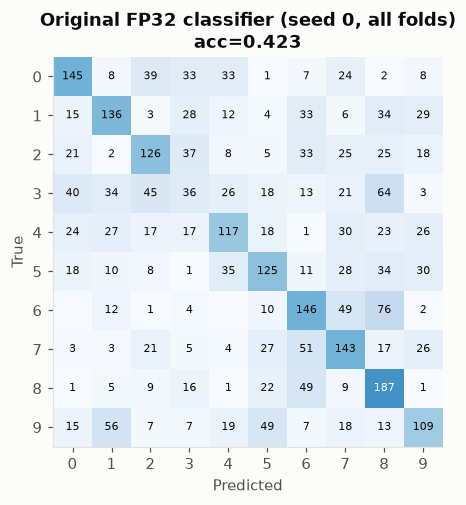

In [5]:
def confmat(df, title, ax):
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(df.label, df.prediction, labels=range(10))
    cmn = cm / cm.sum(1, keepdims=True)
    ax.imshow(cmn, cmap='Blues', vmin=0, vmax=1); ax.grid(False)
    for i in range(10):
        for j in range(10):
            if cm[i, j]:
                ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=7,
                        color='white' if cmn[i, j] > 0.6 else '#0b0b0b')
    ax.set_xticks(range(10)); ax.set_yticks(range(10))
    ax.set(xlabel='Predicted', ylabel='True', title=f'{title}\nacc={df.correct.mean():.3f}')
fig, ax = plt.subplots(figsize=(5, 4.6))
confmat(pr[pr.seed == 0], 'Original FP32 classifier (seed 0, all folds)', ax)
fig.savefig(FIG / 'confusion_original.png'); plt.show()